<a href="https://colab.research.google.com/github/DanielSozoranga/Machine-Learning-6-SIN-A-Mar-Jul-2026/blob/metrics/Bias_Variance_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias and Variance

**Name:**
Daniel Sozoranga

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Shared data for all plots
np.random.seed(42)
n = 50
X = np.sort(np.random.uniform(-np.pi, np.pi, n))
y = np.sin(X) + np.random.normal(0, 0.3, n)
X_plot = np.linspace(-np.pi, np.pi, 300)

def plot_degree(deg):
    pf = PolynomialFeatures(degree=deg)
    Xp = pf.fit_transform(X.reshape(-1, 1))
    model = LinearRegression().fit(Xp, y)
    mse = mean_squared_error(y, model.predict(Xp))
    y_plot = model.predict(pf.transform(X_plot.reshape(-1, 1)))

    plt.figure(figsize=(7, 4))
    plt.scatter(X, y, color='lightgray', s=30, label='Noisy data')
    plt.plot(X_plot, np.sin(X_plot), color='deeppink', linewidth=2, label='True function (sin)')
    plt.plot(X_plot, y_plot, color='#5555dd', linewidth=2, label=f'Prediction (deg {deg})')
    plt.title(f'Polynomial regression (degree {deg})\nMSE: {mse:.4f}', fontsize=12)
    plt.xlabel('X'); plt.ylabel('Y')
    plt.ylim(-1.8, 1.8)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Bias

Bias is the error that comes from using a model that is too simple to capture the true relationship between variables. Inflexible models make strong assumptions about the data. When those assumptions are wrong, the model systematically misses the true pattern regardless of how much data it has. This leads to underfitting.

## Variance

Variance is the error that comes from the model's sensitivity to fluctuations in the training set. If training the model on a slightly different dataset would produce a drastically different result, the model has high variance. Flexible models fit the training noise too closely and fail on new data. This leads to overfitting.

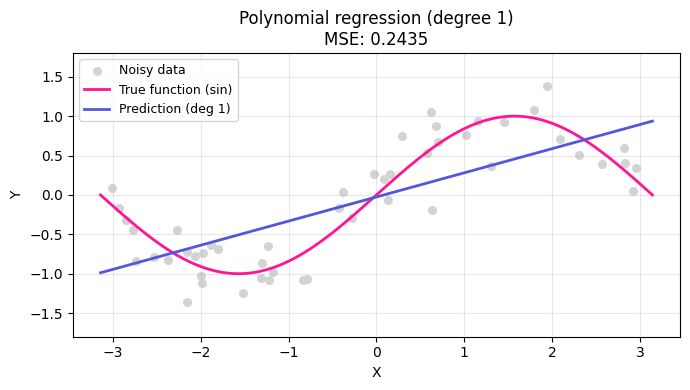

In [3]:
plot_degree(1)

## Degree 1: High Bias, Low Variance (Underfitting)

A degree-1 polynomial is a straight line. The true underlying function is a sine wave, so no matter how much data the model sees, a line can never capture that shape. The error does not come from randomness in the training set — it comes from a fundamentally wrong assumption about the form of the relationship. This is the definition of bias.

The model has low variance because its output barely changes if the training data changes slightly: a line fitted to any 50 noisy samples from this distribution will always look roughly the same. However, low variance does not compensate for high bias. The model is consistently wrong in the same way. The result is underfitting: high training error and high test error.

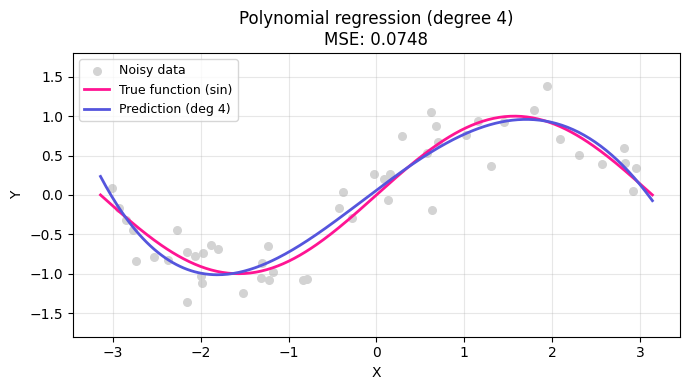

In [4]:
plot_degree(4)

## Degree 4: Low Bias, Low Variance (Balanced)

A degree-4 polynomial has enough flexibility to approximate the shape of a sine wave without memorizing noise. The prediction curve closely follows the true function across the entire input range. This means the model has low bias: its structural assumptions are compatible with the true relationship in the data.

At the same time, a degree-4 model does not have enough free parameters to chase every random fluctuation in the training set. If the training data changed slightly, the resulting curve would remain very similar. This is low variance. The combination of low bias and low variance is the goal of any machine learning model: the training error is low and, crucially, the test error is also low. The model generalizes.

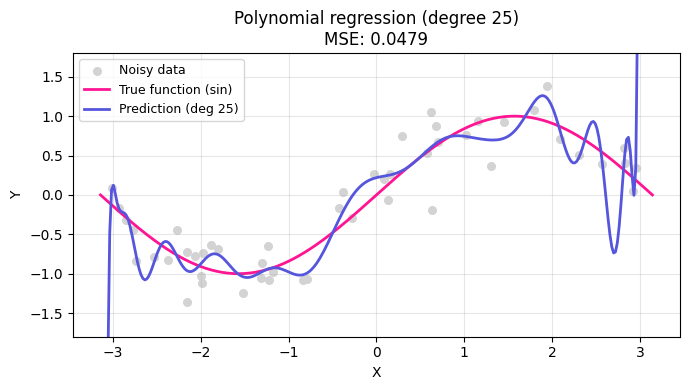

In [5]:
plot_degree(25)

## Degree 25: Low Bias, High Variance (Overfitting)

A degree-25 polynomial has far more parameters than needed to describe a sine wave. During training, the model uses those extra degrees of freedom to fit not only the true signal but also the random noise in each data point. The result is a curve that passes extremely close to every training sample, achieving the lowest training MSE of the three models.

However, this apparent precision is misleading. The noise fitted by the model is specific to this particular set of 50 samples. If the training data changed even slightly, the curve would look completely different — that is the definition of high variance. On new data, the erratic shape of the curve produces large prediction errors. The model has low bias (it is flexible enough to represent the true function) but high variance (it is so sensitive to the training set that it cannot generalize). The result is overfitting: very low training error but high test error.